✓ Libraries imported successfully!
Pandas version: 2.0.3
NumPy version: 1.24.3
✓ Data loaded: (1470, 48)
✓ Target variable: JobSatisfaction

Features shape: (1470, 47)
Target shape: (1470,)
Number of features: 47

Phân phối JobSatisfaction:
  Lớp 1: 289 mẫu (19.66%)
  Lớp 2: 280 mẫu (19.05%)
  Lớp 3: 442 mẫu (30.07%)
  Lớp 4: 459 mẫu (31.22%)
Số thành phần PCA được chọn: 23
Phương sai giải thích: 0.7990

Dữ liệu gốc: (1470, 47)
Dữ liệu PCA: (1470, 23)
Tỉ lệ chia train:test:
  8:2
  7:3
  6:4
✓ All classification models imported!
Đang chạy experiments...
Models được chọn: ['Naive Bayes', 'Logistic Regression', 'SVM']

--- Split ratio: 8:2 ---
  Training Naive Bayes on Original data...
  Training Logistic Regression on Original data...
  Training SVM on Original data...
  Training Naive Bayes on PCA data...
  Training Logistic Regression on PCA data...
  Training SVM on PCA data...

--- Split ratio: 7:3 ---
  Training Naive Bayes on Original data...
  Training Logistic Regression on Orig

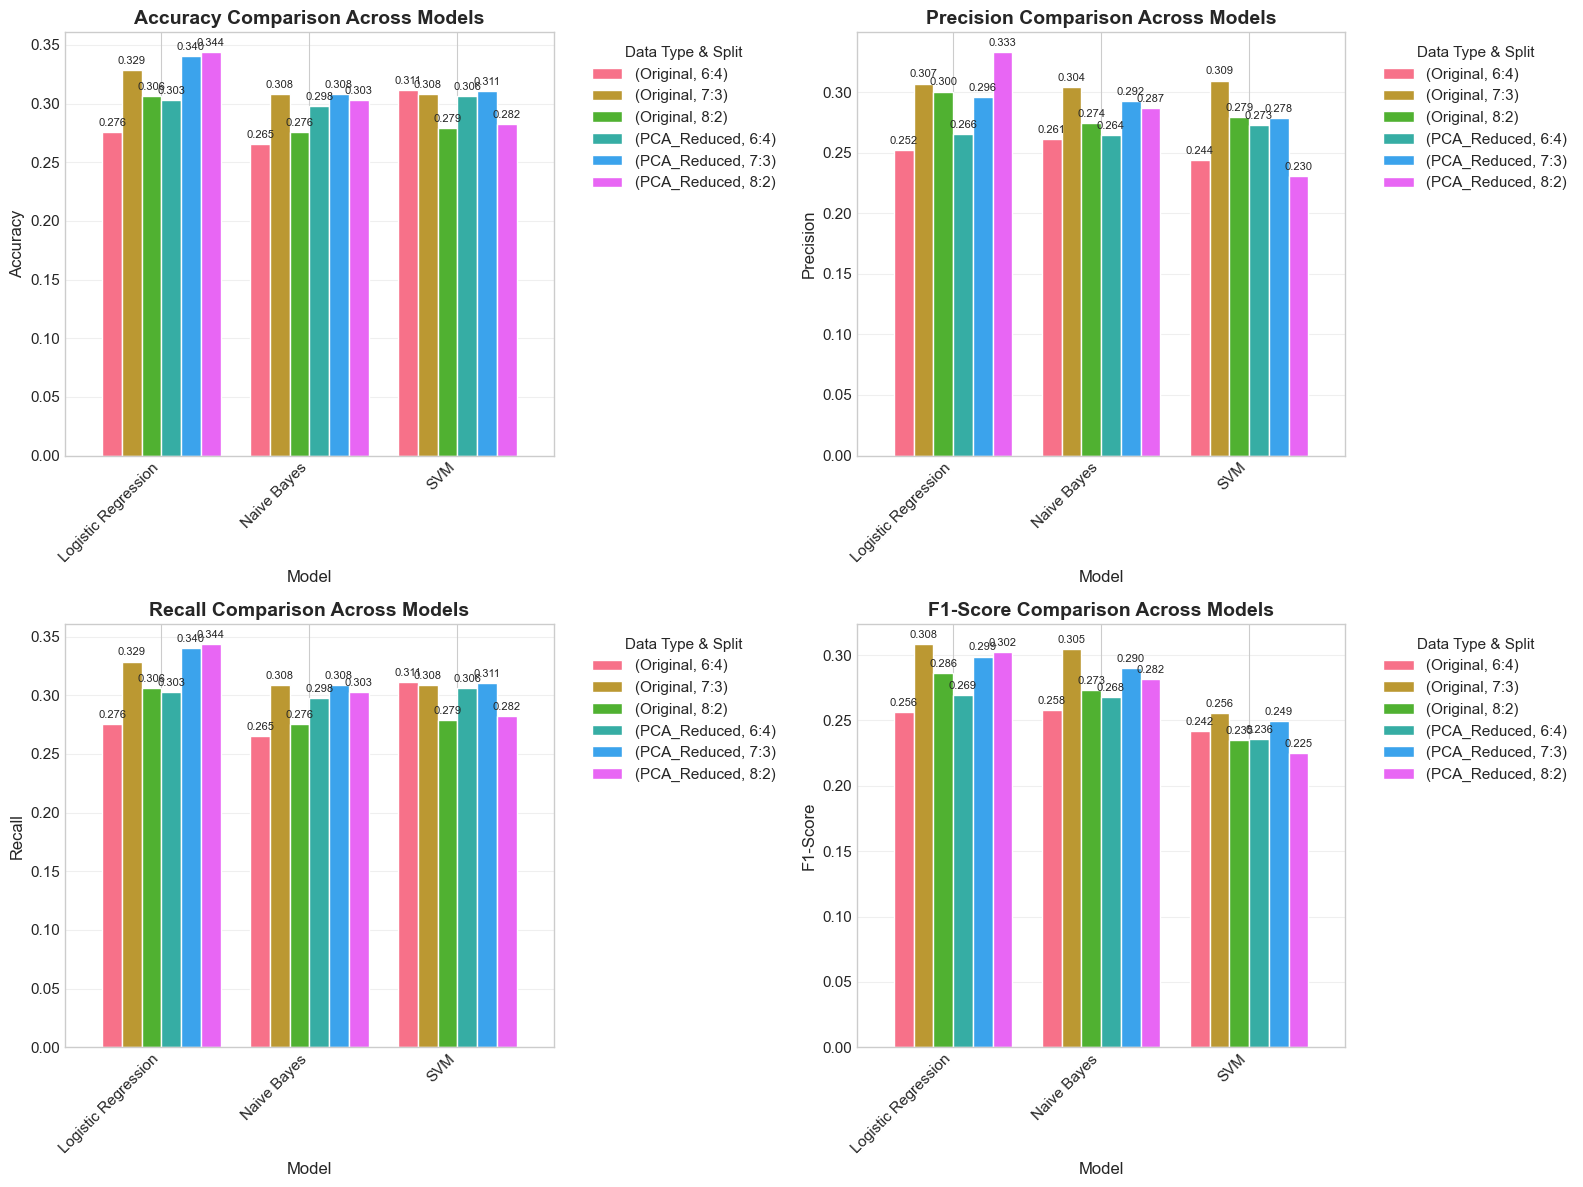


✓ Visualization saved to '../results/classification_comparison.png'


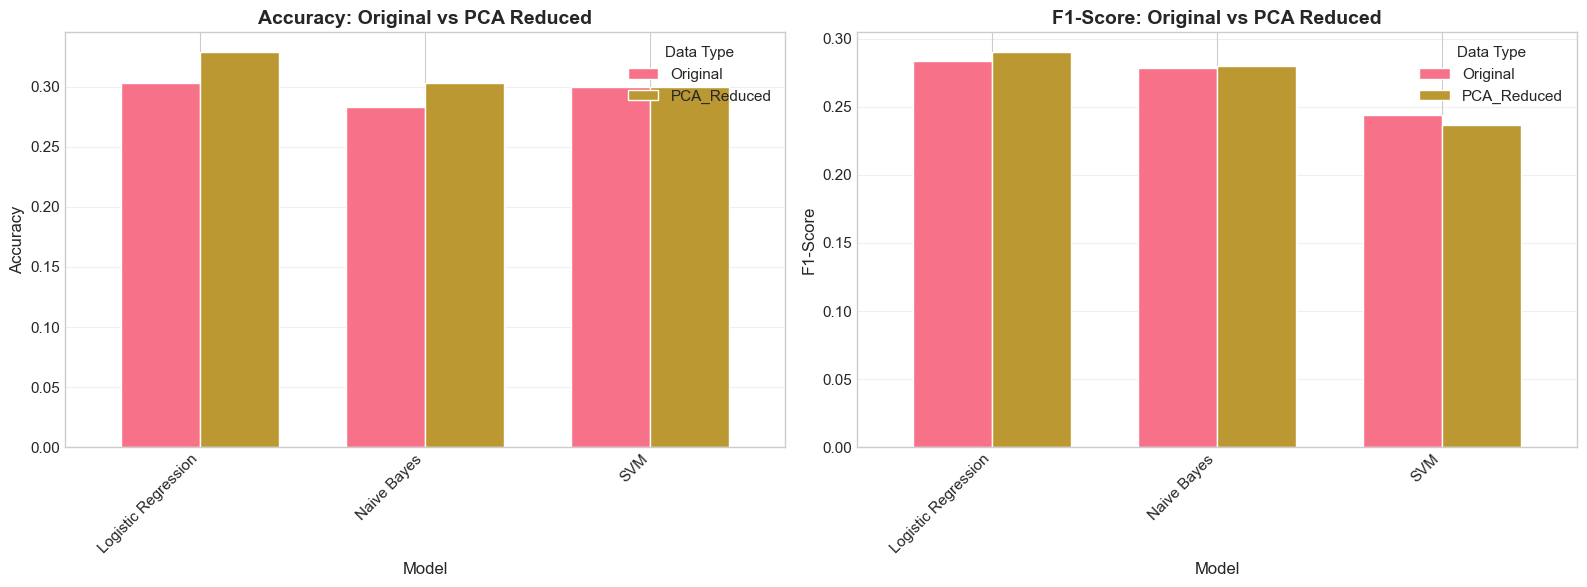


MÔ HÌNH TỐT NHẤT
Model: Logistic Regression
Data Type: Original
Split: 7:3
Accuracy: 0.3288
F1-Score: 0.3082


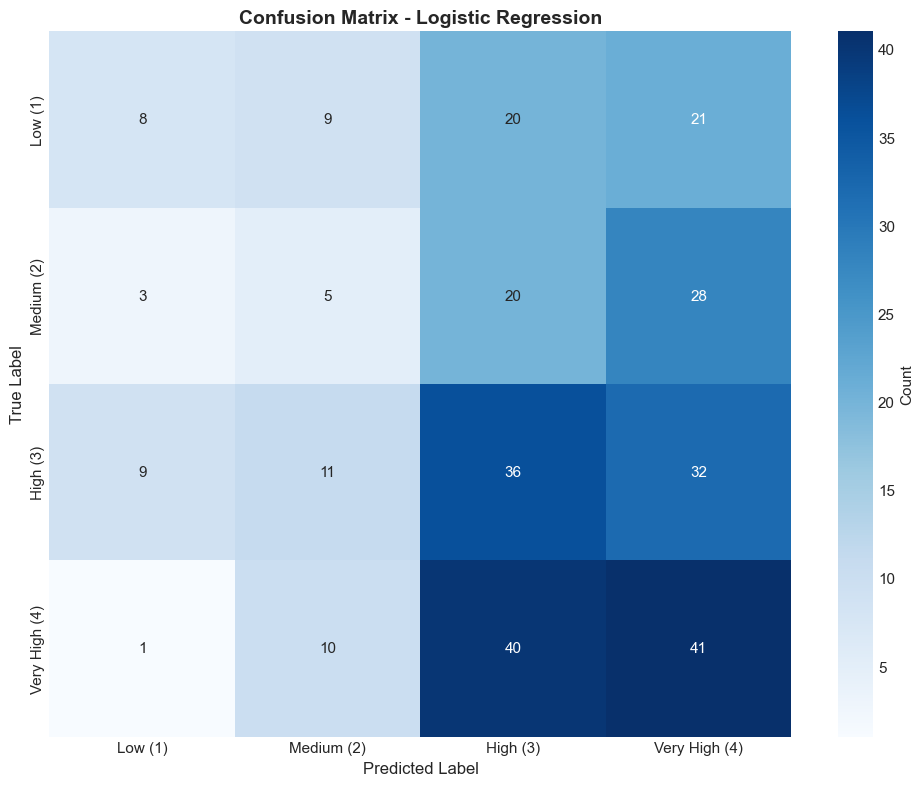


CLASSIFICATION REPORT
               precision    recall  f1-score   support

      Low (1)       0.38      0.14      0.20        58
   Medium (2)       0.14      0.09      0.11        56
     High (3)       0.31      0.41      0.35        88
Very High (4)       0.34      0.45      0.38        92

     accuracy                           0.31       294
    macro avg       0.29      0.27      0.26       294
 weighted avg       0.30      0.31      0.29       294


PHÂN TÍCH OVERFITTING
split               model  train_accuracy  test_accuracy      gap
  8:2         Naive Bayes        0.354592       0.275510 0.079082
  8:2 Logistic Regression        0.383503       0.306122 0.077381
  8:2                 SVM        0.635204       0.278912 0.356293
  7:3         Naive Bayes        0.354713       0.308390 0.046323
  7:3 Logistic Regression        0.387755       0.328798 0.058957
  7:3                 SVM        0.630709       0.308390 0.322319
  6:4         Naive Bayes        0.354875       0

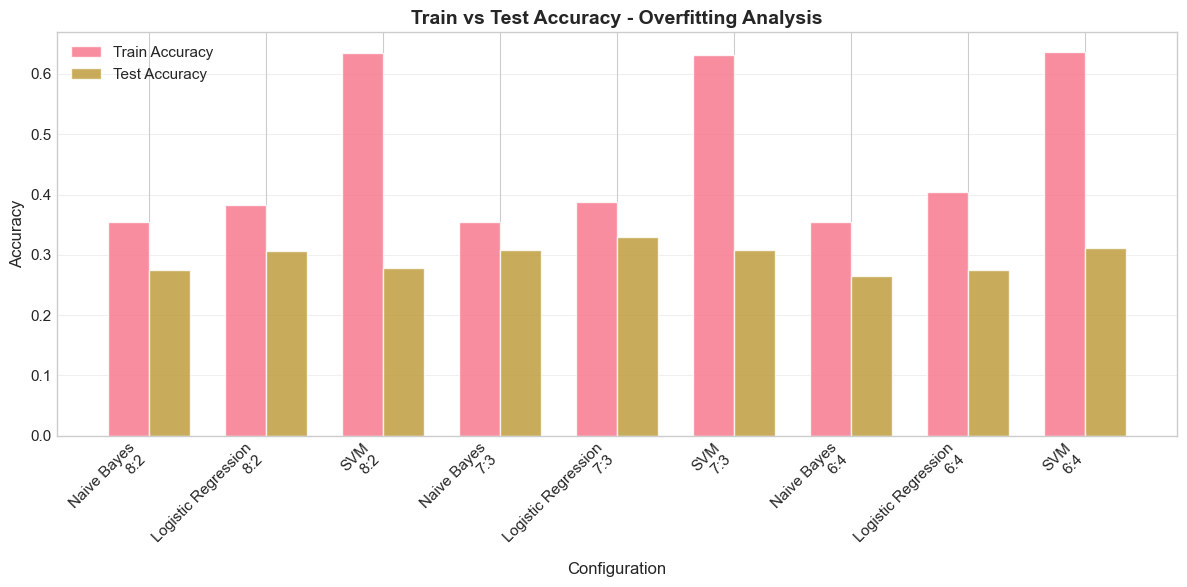


✓ Phân tích overfitting hoàn tất!

KẾT LUẬN

1. ĐÃ THỰC HIỆN:
   - Phân loại JobSatisfaction thành 4 lớp (1, 2, 3, 4)
   - Sử dụng 3 phương pháp từ 3 nhóm khác nhau:
     + Nhóm 1: Naive Bayes
     + Nhóm 2: Logistic Regression
     + Nhóm 3: SVM
   - So sánh trên dữ liệu gốc và dữ liệu giảm chiều (PCA)
   - Đánh giá với 3 tỉ lệ train:test khác nhau (4:1, 7:3, 6:4)

2. NHẬN XÉT:
   - Xem confusion matrix và classification report để đánh giá chi tiết
   - So sánh performance giữa dữ liệu gốc và PCA
   - Phân tích overfitting qua train/test accuracy gap



In [2]:
# NOTEBOOK 5: PHÂN LOẠI (CLASSIFICATION)
# Yêu cầu 2.4(a) và 2.4(b)
# Dự đoán JobSatisfaction (4 lớp: 1, 2, 3, 4)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

## 1. LOAD DỮ LIỆU

import json

# Load data
df = pd.read_csv('../data/processed/data_normalized.csv')
print(f"✓ Data loaded: {df.shape}")

# Load metadata
with open('../data/processed/metadata.json', 'r') as f:
    metadata = json.load(f)

target_col = metadata['target_column']
print(f"✓ Target variable: {target_col}")

# Separate features and target
y = df[target_col].values  # JobSatisfaction: 1, 2, 3, 4
X = df.drop(target_col, axis=1).values
feature_names = df.drop(target_col, axis=1).columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {len(feature_names)}")

# Kiểm tra phân phối các lớp
print(f"\nPhân phối JobSatisfaction:")
unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Lớp {int(val)}: {count} mẫu ({count / len(y) * 100:.2f}%)")

## 2. CHUẨN BỊ DỮ LIỆU GIẢM CHIỀU (PCA)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA giảm chiều (giữ 95% phương sai)
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumsum_variance >= 0.95) + 1
n_components = max(3, min(n_components, X.shape[1] // 2))

print(f"Số thành phần PCA được chọn: {n_components}")
print(f"Phương sai giải thích: {cumsum_variance[n_components - 1]:.4f}")

pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nDữ liệu gốc: {X.shape}")
print(f"Dữ liệu PCA: {X_pca.shape}")

## 3. ĐỊNH NGHĨA CÁC TỈ LỆ CHIA DỮ LIỆU

train_test_splits = [
    (0.8, 0.2),  # 4:1
    (0.7, 0.3),  # 7:3
    (0.6, 0.4)  # 6:4
]

print("Tỉ lệ chia train:test:")
for train_size, test_size in train_test_splits:
    print(f"  {int(train_size * 10)}:{int(test_size * 10)}")

## 4. IMPORT CÁC MÔ HÌNH PHÂN LOẠI
### Từ 3 nhóm khác nhau theo yêu cầu

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Nhóm 1: K-NN, Cây quyết định, Naïve Bayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Nhóm 2: Hồi quy Softmax-Logistic, MLP
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Nhóm 3: SVM
from sklearn.svm import SVC

print("✓ All classification models imported!")


## 5. HÀM TRAIN VÀ ĐÁNH GIÁ

def train_and_evaluate_classification(X_train, X_test, y_train, y_test,
                                      model_name, data_type, split_ratio, results_dict):
    """
    Train và evaluate classification model
    """
    # Khởi tạo models
    models = {
        # Nhóm 1
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
        'Naive Bayes': GaussianNB(),

        # Nhóm 2
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'),
        'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),

        # Nhóm 3
        'SVM': SVC(kernel='rbf', random_state=42, probability=True)
    }

    model = models[model_name]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Lưu kết quả
    results_dict['split'].append(split_ratio)
    results_dict['model'].append(model_name)
    results_dict['data_type'].append(data_type)
    results_dict['accuracy'].append(accuracy)
    results_dict['precision'].append(precision)
    results_dict['recall'].append(recall)
    results_dict['f1'].append(f1)

    return model, y_pred


## 6. CHẠY EXPERIMENTS VỚI TẤT CẢ CÁC MÔ HÌNH

# Dictionary lưu kết quả
results_classification = {
    'split': [],
    'model': [],
    'data_type': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

# Chọn 3 models từ 3 nhóm khác nhau
selected_models = ['Naive Bayes', 'Logistic Regression', 'SVM']  # 3 nhóm khác nhau

print("Đang chạy experiments...")
print(f"Models được chọn: {selected_models}")

for train_size, test_size in train_test_splits:
    split_ratio = f"{int(train_size * 10)}:{int(test_size * 10)}"
    print(f"\n--- Split ratio: {split_ratio} ---")

    # ===== DỮ LIỆU GỐC =====
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    for model_name in selected_models:
        print(f"  Training {model_name} on Original data...")
        train_and_evaluate_classification(
            X_train, X_test, y_train, y_test,
            model_name, 'Original', split_ratio, results_classification
        )

    # ===== DỮ LIỆU GIẢM CHIỀU (PCA) =====
    X_train_pca, X_test_pca, y_train, y_test = train_test_split(
        X_pca, y, test_size=test_size, random_state=42, stratify=y
    )

    for model_name in selected_models:
        print(f"  Training {model_name} on PCA data...")
        train_and_evaluate_classification(
            X_train_pca, X_test_pca, y_train, y_test,
            model_name, 'PCA_Reduced', split_ratio, results_classification
        )

print("\n✓ Experiments completed!")

## 7. HIỂN THỊ KẾT QUẢ

# Tạo DataFrame kết quả
results_df = pd.DataFrame(results_classification)

print("\n" + "=" * 80)
print("KẾT QUẢ PHÂN LOẠI (CLASSIFICATION RESULTS)")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Tính trung bình theo model và data type
print("\n--- Trung bình theo Model và Data Type ---")
avg_results = results_df.groupby(['model', 'data_type'])[['accuracy', 'precision', 'recall', 'f1']].mean()
print(avg_results)

## 8. TRỰC QUAN HÓA KẾT QUẢ

# Visualize kết quả
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx // 2, idx % 2]

    pivot_table = results_df.pivot_table(
        values=metric,
        index='model',
        columns=['data_type', 'split'],
        aggfunc='mean'
    )

    pivot_table.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(f'{label} Comparison Across Models', fontsize=14, fontweight='bold')
    ax.set_ylabel(label, fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.legend(title='Data Type & Split', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Thêm giá trị trên các cột
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('../results/classification_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to '../results/classification_comparison.png'")

## 9. SO SÁNH DỮ LIỆU GỐC VS GIẢM CHIỀU

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# So sánh Accuracy
comparison_data = results_df.groupby(['model', 'data_type'])['accuracy'].mean().unstack()
comparison_data.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('Accuracy: Original vs PCA Reduced', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].legend(title='Data Type')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# So sánh F1-Score
comparison_data = results_df.groupby(['model', 'data_type'])['f1'].mean().unstack()
comparison_data.plot(kind='bar', ax=axes[1], width=0.7)
axes[1].set_title('F1-Score: Original vs PCA Reduced', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].legend(title='Data Type')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../results/original_vs_pca.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. CONFUSION MATRIX CHO MÔ HÌNH TỐT NHẤT

# Tìm mô hình tốt nhất dựa trên F1-score
best_idx = results_df['f1'].idxmax()
best_config = results_df.iloc[best_idx]

print("\n" + "=" * 80)
print("MÔ HÌNH TỐT NHẤT")
print("=" * 80)
print(f"Model: {best_config['model']}")
print(f"Data Type: {best_config['data_type']}")
print(f"Split: {best_config['split']}")
print(f"Accuracy: {best_config['accuracy']:.4f}")
print(f"F1-Score: {best_config['f1']:.4f}")
print("=" * 80)

# Train lại mô hình tốt nhất để vẽ confusion matrix
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Khởi tạo và train mô hình tốt nhất
if best_config['model'] == 'Naive Bayes':
    best_model = GaussianNB()
elif best_config['model'] == 'Logistic Regression':
    best_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
elif best_config['model'] == 'SVM':
    best_model = SVC(kernel='rbf', random_state=42, probability=True)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)'],
            yticklabels=['Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_config["model"]}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../results/confusion_matrix_best.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(y_test, y_pred,
                            target_names=['Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)']))

## 11. PHÂN TÍCH OVERFITTING

print("\n" + "=" * 80)
print("PHÂN TÍCH OVERFITTING")
print("=" * 80)

# Train lại với các split khác nhau và so sánh train vs test accuracy
splits_analysis = []

for train_size, test_size in train_test_splits:
    split_ratio = f"{int(train_size * 10)}:{int(test_size * 10)}"

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    for model_name in selected_models:
        if model_name == 'Naive Bayes':
            model = GaussianNB()
        elif model_name == 'Logistic Regression':
            model = LogisticRegression(max_iter=1000, random_state=42)
        elif model_name == 'SVM':
            model = SVC(kernel='rbf', random_state=42)

        model.fit(X_train, y_train)

        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        gap = train_acc - test_acc

        splits_analysis.append({
            'split': split_ratio,
            'model': model_name,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'gap': gap
        })

overfitting_df = pd.DataFrame(splits_analysis)
print(overfitting_df.to_string(index=False))

# Vẽ biểu đồ overfitting
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(overfitting_df))
width = 0.35

ax.bar(x - width / 2, overfitting_df['train_accuracy'], width, label='Train Accuracy', alpha=0.8)
ax.bar(x + width / 2, overfitting_df['test_accuracy'], width, label='Test Accuracy', alpha=0.8)

ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Train vs Test Accuracy - Overfitting Analysis', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['model']}\n{row['split']}"
                    for _, row in overfitting_df.iterrows()],
                   rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Phân tích overfitting hoàn tất!")

## 12. KẾT LUẬN

print("\n" + "=" * 80)
print("KẾT LUẬN")
print("=" * 80)

print("""
1. ĐÃ THỰC HIỆN:
   - Phân loại JobSatisfaction thành 4 lớp (1, 2, 3, 4)
   - Sử dụng 3 phương pháp từ 3 nhóm khác nhau:
     + Nhóm 1: Naive Bayes
     + Nhóm 2: Logistic Regression
     + Nhóm 3: SVM
   - So sánh trên dữ liệu gốc và dữ liệu giảm chiều (PCA)
   - Đánh giá với 3 tỉ lệ train:test khác nhau (4:1, 7:3, 6:4)

2. NHẬN XÉT:
   - Xem confusion matrix và classification report để đánh giá chi tiết
   - So sánh performance giữa dữ liệu gốc và PCA
   - Phân tích overfitting qua train/test accuracy gap
""")

print("=" * 80)